In [2]:
import pandas as pd
import numpy as np
from scipy.stats import skewnorm
import seaborn as sns
from efficient_apriori import apriori
import re
import numpy as np
import random
import statistics

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
datas = pd.read_csv('PSCompPars_2025.06.12_09.54.16.csv', comment='#', low_memory=False)
data = pd.DataFrame(data=datas)
origdata = data.copy(deep = True)
#These two were labeled incorrectly on the dataframe
data.replace({ 'st_spectype': {'m3 V':'M V'} }, inplace = True)
data.replace({ 'st_spectype': {'sdBV':'B V'} }, inplace = True)

In [4]:
#assigns random temperature for each planet
def rand_temp(row):
    try:
        mean = row['pl_eqt'] + ((row['pl_eqterr1']+row['pl_eqterr2'])/2)
        sd = row['pl_eqt'] + row['pl_eqterr1'] - mean
        a = (3*(mean-row['pl_eqt']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_eqterr1'], size=1)[0]
    except:
        return row['pl_eqt']

#assigns random planet radius:  
def rand_prade(row):
    try:
        mean = row['pl_rade'] + ((row['pl_radeerr1']+row['pl_radeerr2'])/2)
        sd = row['pl_rade'] + row['pl_radeerr1'] - mean
        a = (3*(mean-row['pl_rade']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_radeerr1'], size=1)[0]
    except:
        return row['pl_rade']

#assigns random planet semimajor axis: 
def rand_majoraxis(row):
    try:
        mean = row['pl_orbsmax'] + ((row['pl_orbsmaxerr1']+row['pl_orbsmaxerr2'])/2)
        sd = row['pl_orbsmax'] + row['pl_orbsmaxerr1'] - mean
        a = (3*(mean-row['pl_orbsmax']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbsmaxerr1'], size=1)[0]
    except: 
        return row['pl_orbsmax']

#assigns random planet orbital period:
def rand_orbper(row):
    try:
        mean = row['pl_orbper'] + ((row['pl_orbpererr1']+row['pl_orbpererr2'])/2)
        sd = row['pl_orbper'] + row['pl_orbpererr1'] - mean
        a = (3*(mean-row['pl_orbper']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbpererr1'], size=1)[0]
    except: 
        return row['pl_orbper']

#estimates the semimajor axis given a row of a data frame given stellar mass and orbital period: Kepler's 3rd law
#Only estimates the semimajor axis if the value is originally NaN
def estimate_orbsmax(row):
    if pd.isna(row['pl_orbsmax']):
        try: 
            return (((6.67e-11 * (row['st_mass'] * 1.989e30) * ((row['pl_orbper'] * 86400)**2)) / (4 * (np.pi**2)))**(1/3)) / 1.496e11
        except:
            return np.nan
    else:
        return row['pl_orbsmax']
        

#Sets the spectral type if it is already in the string for the spectype variable for each row.
#Otherwise, it is estimated based on equillibrium temperature.
def get_spectype(row):
    try: 
        return row['st_spectype'][0]
    except:
        if(row['st_teff']>=30000):
            return 'O'
        elif(row['st_teff']>=10000):
            return 'B'
        elif(row['st_teff']>=7500):
            return 'A'
        elif(row['st_teff']>=6000):
            return 'F'
        elif(row['st_teff']>=5200):
            return 'G'
        elif(row['st_teff']>=3700):
            return 'K'
        elif(row['st_teff']>=2400):
            return 'M'
        else:
            return row['st_spectype']

#Estimates the equillibrium temperature of a row given stellar luminosity, and semimajor axis
#Only estimates if there is a missing value for pl_eqt: Stefan-Boltzmann's law
def estimate_pl_eqt(row):
    if pd.isna(row['pl_eqt']):
        try:
            return (((10 ** row['st_lum']) * 3.827e26) / (16 * np.pi * 5.67e-8 * ((row['pl_orbsmax'] * 1.496e11) ** 2))) ** (1 / 4)
        except:
            return np.nan
    else:
        return row['pl_eqt']


#Grabs the last value of the string, usually the Luminosity Class of the star
#Otherwise, estimates whethoer or not the star is main sequence based on the luminosity of the star
def is_mainsequence(row):
    if(str(row['st_spectype'])[-1] == ('V') and str(row['st_spectype'])[-2:] != ('IV')):
        return 'True'
    else:
        try:
            if(str(row['spectype']).__contains__('M') and row['st_lum'] < -1.0969):
                return 'True'
            elif(str(row['spectype']).__contains__('K') and row['st_lum'] < -0.2218):
                return 'True'
            elif(str(row['spectype']).__contains__('G') and row['st_lum'] < 0.1761):
                return 'True'
            elif(str(row['spectype']).__contains__('F') and row['st_lum'] < 0.699):
                return 'True'
            elif(str(row['spectype']).__contains__('A') and row['st_lum'] < 1.3979):
                return 'True'
            elif(str(row['spectype']).__contains__('B') and row['st_lum'] < 4.477):
                return 'True'
            elif(str(row['spectype']).__contains__('O')):
                return 'True'
            else:
                return 'False'
        except:
            return 'False'   

#Gets the right hand and left hand side of the rule and puts it in an items list
pl_pattern = re.compile(r'(.+?)(\d)')
def parse_rule(rule_str):
    lhs, rhs = rule_str.split('->')
    lhs_items = [item.strip() for item in lhs.strip('{} ').split(',')]
    rhs = rhs.split("{")[1].split("}")[0]
    rhs_items = [item.strip() for item in rhs.strip('{} ').split(',')]
    return lhs_items, rhs_items

#Puts items in a system into a dictionary so that they are easy to compare, get counts for classifications
def get_plnum_dict(items):
    orbital_dict = {}
    for item in items:
        match = pl_pattern.match(item)
        if match:
            base_type, number = match.groups()
            number = int(number)
            orbital_dict.setdefault(base_type, set()).add(number)
    return orbital_dict

def number_classes(group, column):
    seen = {}
    labels = []
    for clss in group[column]:
        seen[clss] = seen.get(clss, 0) + 1
        labels.append(f"{clss}{seen[clss]}")
    return labels

systemstrain = {}
systemstest = {}
def get_classlist(hostname, dataset, plonly):
    lists = []
    if dataset.Name == 'trainset':
        if str(hostname) in systemstrain:
            return systemstrain[str(hostname)]
        for _, row in dataset.iterrows():
            if row['hostname'] == hostname:
                if plonly == 1:
                    lists.append(row['pl_class'])
                elif plonly == 0:
                  lists.append(row['stars_class'])
                else:
                    raise KeyError("plonly must be 0 or 1")
        systemstrain[str(hostname)] = lists
    if str(dataset) == 'testset':
        if str(hostname) in systemstest:
            return systemstest[str(hostname)]
        for _, row in dataset.iterrows():
            if row['hostname'] == hostname:
                if plonly == 1:
                    lists.append(row['pl_class'])
                elif plonly == 0:
                  lists.append(row['stars_class'])
                else:
                    raise KeyError("plonly must be 0 or 1")
        systemstest[str(hostname)] = lists
    return lists


def build_class_map(df, plonly):
    if plonly == 1:
        class_col = 'pl_class'
    elif plonly == 0:
        class_col = 'stars_class'
    else:
        raise ValueError("plonly must be 0 or 1")
    
    return df.groupby('hostname')[class_col].apply(list).to_dict()


In [92]:
#percent of the dataset that is going to be used for the prediction (ex: =.7 -> 70% will predict the other 30%)
percentageused = .55
univnum = 100

In [93]:
wedidit_list = {}
idea = []
confidenceforrules = {}
for i in range(univnum):
    systemstrain = {}
    systemstest = {}
    data = origdata.copy(deep= True)
    #applying all of the non-random variables
    data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
    data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
    data['spectype'] = data.apply(get_spectype, axis = 1)
    data['isMS'] = data.apply(is_mainsequence, axis = 1)
    #Remove systems with more that one host star
    star = data.loc[data['sy_snum'] < 2]
    # Excluded planet systems that did not have any data on the variables of interest
    star = star.loc[star['pl_orbper'].isna() == False]
    star = star.loc[star['pl_rade'].isna() == False]
    star = star.loc[star['st_teff'].isna() == False]
    star = star.loc[star['pl_eqt'].isna() == False]
    star = star.loc[star['spectype'].isna() == False]
    star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
    star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
    star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
    star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
    star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
    star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
    teststr = 'hostname'
    star['pl_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'pl_class'), index=g.index)).reset_index(level=0, drop=True))
    star['stars_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'stars_class'), index=g.index)).reset_index(level=0, drop=True))
    
    #Creating a dataframe with only main sequence stars and their proper classificaiton
    onlyMS = star.loc[star['isMS'] == 'True']
    trainset = pd.DataFrame()
    trainset = onlyMS.sample(frac=percentageused, random_state= random.randint(1, 1000))
    testset = pd.DataFrame()
    testset = onlyMS.drop(trainset.index)


    #originally 55 only MS and pl class
    test = {'type': trainset['pl_class'],'host':trainset['hostname']}
    plon = 1

    #originally 92 only MS and pl+star class
    '''test = {'type': testset['stars_class'],'host':testset['hostname']}
    plon = 0'''

    #originally 70 all stars and pl class
    '''test = {'type': testset['pl_class'],'host':testset['hostname']}
    plon = 1'''

    #Originally 103 all stars and pl+st class
    '''test = {'type': testset['stars_class'],'host':testset['hostname']}
    plon = 0'''

    testing = pd.DataFrame(data=test)
    repeats = testing.groupby('host')

    #Put into tuples by host star for the package. Adds the counts as well
    modified_tuples = []
    for host, group in repeats:
            modified_tuples.append(tuple(group['type']))
    origitemset, origrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)
    filtered_rules = []
    #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
    for rule in origrules:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        lhs_plnum = get_plnum_dict(lhs_items)
        rhs_plnum = get_plnum_dict(rhs_items)
        all_items = lhs_items + rhs_items
        all_plnum = get_plnum_dict(all_items)
        rule_valid = True
        for base_type, plnums in lhs_plnum.items():
            for num in plnums:
                if num > 1:
                    required = set(range(1, num))
                    if not required.issubset(plnums):
                        rule_valid = False
                        break
            if not rule_valid:
                break
        for base_type, plnum in rhs_plnum.items():
            if not rule_valid:
                break
            for items in plnum:
                if items > 1:
                    required = set(range(1, items))
                    if not required.issubset(all_plnum[base_type]):
                        rule_valid = False
                        break
        if rule_valid:
            filtered_rules.append(rule)


    wedidit = 0
    answers = {}
    testset.Name = 'testset'
    trainset.Name = 'trainset'
    systemstrain = build_class_map(trainset, plonly=1)
    systemstest = build_class_map(testset, plonly=1)
    for rule in filtered_rules:
        lhs_items, rhs_items = parse_rule(str(rule))
        for host in onlyMS['hostname'].unique():
            train_planets = systemstrain.get(host, [])
            test_planets = systemstest.get(host, [])
            if all(lhs in train_planets for lhs in lhs_items):
                if any(rhs in test_planets for rhs in rhs_items):
                    wedidit += 1
                    if not i in confidenceforrules:
                        confidenceforrules[i] = []
                    confidenceforrules[i].append([rule.lift, rule.confidence, rule.conviction])
                    answers[str(lhs_items + rhs_items)] = [train_planets, test_planets]
                    break
    try:
        wedidit_list[i] = wedidit / len(filtered_rules)
    except:
        pass

/var/folders/5x/kfc28dn92vg9sprll4rhh2t40000gq/T/ipykernel_1457/997272006.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star['pl_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'pl_class'), index=g.index)).reset_index(level=0, drop=True))
/var/folders/5x/kfc28dn92vg9sprll4rhh2t40000gq/T/ipykernel_1457/997272006.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star['st

number of correct predictions on last simulation 0
number of rules on last simulation 0
the median value of the dataset is  0.1111111111111111
the mean value for the dataset is  0.14846764346764346
the count for the dataset is  100


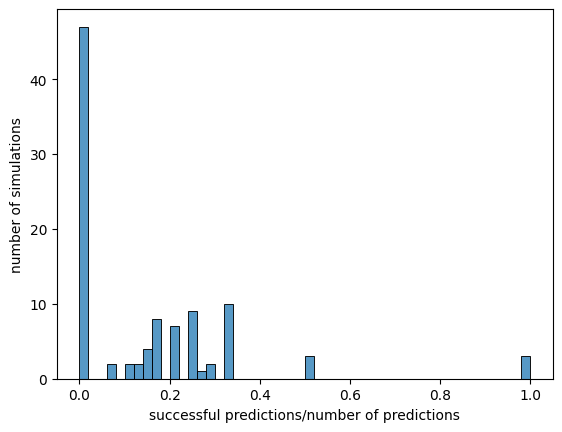

In [117]:
print('number of correct predictions on last simulation ' + str(wedidit))
print('number of rules on last simulation ' + str(len(filtered_rules)))
plot = sns.histplot(x = [wedidit_list[i] for i in wedidit_list], bins = 50)
plot.set(xlabel = 'successful predictions/number of predictions', ylabel = 'number of simulations')
print(f'the median value of the dataset is ', statistics.median([wedidit_list[i] for i in wedidit_list]))
print(f'the mean value for the dataset is ', (sum(wedidit_list.values())/len(wedidit_list)))
print(f'the count for the dataset is ', len(wedidit_list))

In [115]:
wedidit_list

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.26666666666666666,
 4: 0.0,
 5: 0.16666666666666666,
 6: 0.2,
 7: 0.0,
 8: 1.0,
 9: 0.3333333333333333,
 10: 0.2,
 11: 0.5,
 12: 0.16666666666666666,
 13: 0.0,
 14: 0.5,
 15: 0.0,
 16: 0.3333333333333333,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.25,
 21: 0.25,
 22: 0.16666666666666666,
 23: 0.25,
 24: 0.25,
 25: 0.0,
 26: 0.16666666666666666,
 27: 0.2857142857142857,
 28: 0.125,
 29: 0.0,
 30: 0.0,
 31: 0.16666666666666666,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.16666666666666666,
 36: 0.3333333333333333,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.0,
 44: 0.0,
 45: 0.14285714285714285,
 46: 0.0,
 47: 0.2,
 48: 1.0,
 49: 0.07142857142857142,
 50: 0.0,
 51: 0.2,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 1.0,
 56: 0.2,
 57: 0.0,
 58: 0.0,
 59: 0.16666666666666666,
 60: 0.3333333333333333,
 61: 0.0,
 62: 0.3333333333333333,
 63: 0.16666666666666666,
 64: 0.07692307692307693,
 65: 0.25,
 66: 0.2,
 67: 0.3333333333333333,
 68: 0.14285714285714285,


In [96]:
print(len(confidenceforrules))
print(len(wedidit_list))
confidenceforrules

53
100


{3: [[138.0, 0.6666666666666666, 2.9855072374202893],
  [2.011879049676026, 0.5, 1.5029522245840043],
  [7.2631578947368425, 0.6666666666666666, 2.724637672985507],
  [28.227272727272727, 0.5, 1.9645732649919487]],
 5: [[4.113333333333333, 0.5, 1.7568881650437602]],
 6: [[2.063736263736264, 0.5, 1.5154419565005326]],
 8: [[2.104026845637584, 0.5, 1.5247208900925042]],
 9: [[2.8272171253822633, 0.6666666666666666, 2.29259058263007]],
 10: [[13.049295774647888, 0.5, 1.9233675082957367]],
 11: [[46.800000000000004, 0.5, 1.978632474675214]],
 12: [[4.113333333333333, 0.5, 1.7568881650437602]],
 14: [[15.254098360655739, 0.5, 1.9344438435249867]],
 16: [[12.480000000000002, 0.5, 1.9198717910320515]],
 20: [[6.042025862068965, 0.75, 3.5034777815987157]],
 21: [[2.169724770642202, 0.5, 1.539112047661734]],
 22: [[61.93333333333333, 0.6666666666666666, 2.967707203152852]],
 23: [[4.173333333333334, 0.5, 1.760383383060703]],
 24: [[2.0217391304347823, 0.5, 1.505376341075269]],
 26: [[2.27250608

61


[Text(0.5, 0, 'lift'), Text(0, 0.5, 'percent of right rules')]

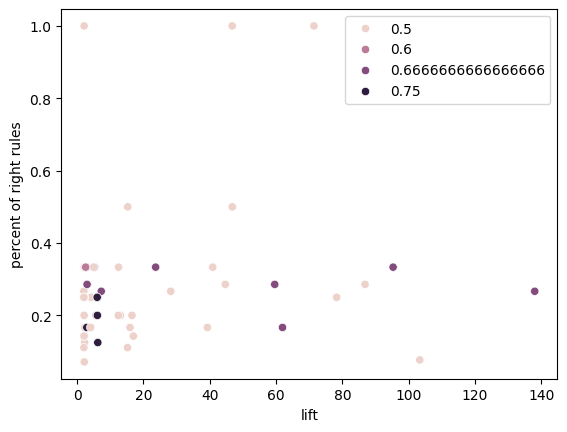

In [98]:
coordinates = []
for i in confidenceforrules:
    for x in confidenceforrules[i]:
        coordinates.append([wedidit_list[i], x[0],x[1]] )
print(len(coordinates))
scatter = sns.scatterplot(y = [i[0] for i in coordinates], x = [i[1] for i in coordinates], hue = [i[2] for i in coordinates])#, legend = False)
scatter.set(xlabel = 'lift', ylabel = 'percent of right rules')

53


[Text(0.5, 0, 'conviction'), Text(0, 0.5, 'percent of right rules')]

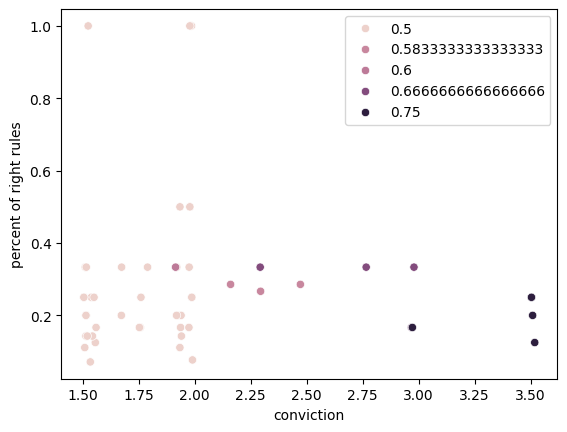

In [102]:
coordinates = []
for i in wedidit_list:
    if wedidit_list[i]>0:
        avgconfidence = 0
        avglift = 0
        for x in confidenceforrules[i]:
            avgconfidence+=x[1]
            avglift +=x[2]
        avgconfidence/=len(confidenceforrules[i])
        avglift/=len(confidenceforrules[i])
        coordinates.append([wedidit_list[i], avglift, avgconfidence] )
print(len(coordinates))
scatter = sns.scatterplot(y = [i[0] for i in coordinates], x = [i[1] for i in coordinates], hue = [i[2] for i in coordinates])#, legend = False)
scatter.set(xlabel = 'conviction', ylabel = 'percent of right rules')

In [100]:
wedidit_list2 = {}

In [103]:
percentageused = 0
onehundredpercent = {}
zerorules = []
number = 0
zeropercent = []
zero = 1
zeros = 0
count = []
hundredpercentrules = {}
while percentageused<=.9:
    percentageused+=.05
    for i in range(10):
        systemstrain = {}
        systemstest = {}
        data = origdata.copy(deep= True)
        #applying all of the non-random variables
        data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
        data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
        data['spectype'] = data.apply(get_spectype, axis = 1)
        data['isMS'] = data.apply(is_mainsequence, axis = 1)
        #Remove systems with more that one host star
        star = data.loc[data['sy_snum'] < 2]
        # Excluded planet systems that did not have any data on the variables of interest
        star = star.loc[star['pl_orbper'].isna() == False]
        star = star.loc[star['pl_rade'].isna() == False]
        star = star.loc[star['st_teff'].isna() == False]
        star = star.loc[star['pl_eqt'].isna() == False]
        star = star.loc[star['spectype'].isna() == False]
        star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
        star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
        star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
        star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
        star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
        star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
        teststr = 'hostname'
        star['pl_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'pl_class'), index=g.index)).reset_index(level=0, drop=True))
        star['stars_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'stars_class'), index=g.index)).reset_index(level=0, drop=True))
        
        #Creating a dataframe with only main sequence stars and their proper classificaiton
        onlyMS = star.loc[star['isMS'] == 'True']
        trainset = pd.DataFrame()
        trainset = onlyMS.sample(frac=percentageused, random_state= random.randint(1, 1000))
        testset = pd.DataFrame()
        testset = onlyMS.drop(trainset.index)


        #originally 55 only MS and pl class
        '''test = {'type': trainset['pl_class'],'host':trainset['hostname']}
        plon = 1'''

        #originally 92 only MS and pl+star class
        '''test = {'type': testset['stars_class'],'host':testset['hostname']}
        plon = 0'''

        #originally 70 all stars and pl class
        test = {'type': testset['pl_class'],'host':testset['hostname']}
        plon = 1

        #Originally 103 all stars and pl+st class
        '''test = {'type': testset['stars_class'],'host':testset['hostname']}
        plon = 0'''

        testing = pd.DataFrame(data=test)
        repeats = testing.groupby('host')

        #Put into tuples by host star for the package. Adds the counts as well
        modified_tuples = []
        for host, group in repeats:
                modified_tuples.append(tuple(group['type']))
        origitemset, origrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)
        filtered_rules = []
        #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
        for rule in origrules:
            rule_str = str(rule)
            lhs_items, rhs_items = parse_rule(rule_str)
            lhs_plnum = get_plnum_dict(lhs_items)
            rhs_plnum = get_plnum_dict(rhs_items)
            all_items = lhs_items + rhs_items
            all_plnum = get_plnum_dict(all_items)
            rule_valid = True
            for base_type, plnums in lhs_plnum.items():
                for num in plnums:
                    if num > 1:
                        required = set(range(1, num))
                        if not required.issubset(plnums):
                            rule_valid = False
                            break
                if not rule_valid:
                    break
            for base_type, plnum in rhs_plnum.items():
                if not rule_valid:
                    break
                for items in plnum:
                    if items > 1:
                        required = set(range(1, items))
                        if not required.issubset(all_plnum[base_type]):
                            rule_valid = False
                            break
            if rule_valid:
                filtered_rules.append(rule)
        wedidit = 0
        answers = {}
        testset.Name = 'testset'
        trainset.Name = 'trainset'
        systemstrain = build_class_map(trainset, plonly=1)
        systemstest = build_class_map(testset, plonly=1)
        for rule in filtered_rules:
            lhs_items, rhs_items = parse_rule(str(rule))
            for host in onlyMS['hostname'].unique():
                train_planets = systemstrain.get(host, [])
                test_planets = systemstest.get(host, [])
                if all(lhs in train_planets for lhs in lhs_items):
                    if any(rhs in test_planets for rhs in rhs_items):
                        wedidit += 1
                        answers[str(lhs_items + rhs_items)] = [train_planets, test_planets]
                        break
        if not percentageused in wedidit_list2:
            wedidit_list2[percentageused] = []
        try:
            wedidit_list2[percentageused].append(wedidit / len(filtered_rules))
        except:
            pass
        if wedidit == len(filtered_rules) and wedidit>0:
            onehundredpercent[number] = trainset['pl_class'].values
            hundredpercentrules[number] = filtered_rules
            number+=1
            if zeros == 0:
                zero = 0
                zeros+=1
        if wedidit == 0:
            if zero == 0:
                zeropercent = trainset['pl_class'].values
                zerorules = filtered_rules
                zero+=1
        count.append(len(filtered_rules))

/var/folders/5x/kfc28dn92vg9sprll4rhh2t40000gq/T/ipykernel_1457/4156063891.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star['pl_class'] = (star.groupby(teststr).apply(lambda g: pd.Series(number_classes(g, 'pl_class'), index=g.index)).reset_index(level=0, drop=True))
/var/folders/5x/kfc28dn92vg9sprll4rhh2t40000gq/T/ipykernel_1457/4156063891.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star['

there were 20 simulations for each bin size


[Text(0.5, 0, 'percentage of data used to train the model'),
 Text(0, 0.5, 'correct rules/total number of rules'),
 Text(0.5, 1.0, 'percent correct rules per training proportion')]

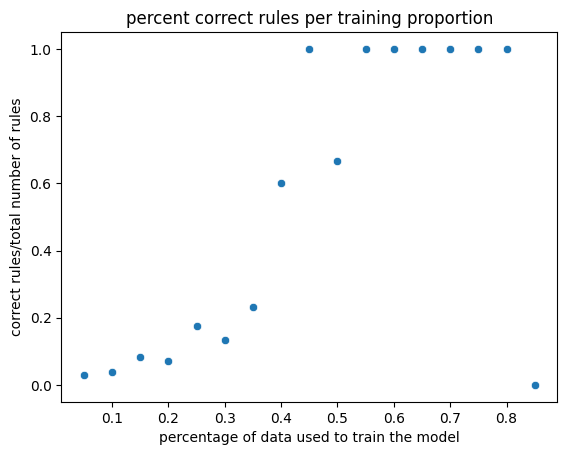

In [110]:
average = []
print(f'there were {len(wedidit_list2[.05])} simulations for each bin size')
for i in wedidit_list2:
    try:
        average.append(sum(wedidit_list2[i])/len(wedidit_list2[i]))
    except:
        average.append(0)
#scatterplot = sns.scatterplot(x = [i for i in wedidit_list2], y = average) #mean
#scatterplot = sns.scatterplot(x = [i for i in wedidit_list2 if len(wedidit_list2[i])>0], y = [statistics.median(wedidit_list2[i]) for i in wedidit_list2 if len(wedidit_list2[i])>0]) #median
scatterplot = sns.scatterplot(x = [i for i in wedidit_list2 if len(wedidit_list2[i])>0], y = [max(wedidit_list2[i]) for i in wedidit_list2 if len(wedidit_list2[i])>0]) #maximum

scatterplot.set(xlabel = 'percentage of data used to train the model', ylabel = 'correct rules/total number of rules', title= 'percent correct rules per training proportion')

In [111]:
print([i for i in wedidit_list2 if len(wedidit_list2[i])>0])

[0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.3, 0.35, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002]


In [112]:
perfectlist = list(onehundredpercent[0])
print(f'number of simulations with 100% rule success rate:', len(onehundredpercent))
a = len(perfectlist)
importantplanets = []
for i in onehundredpercent:
    testinglist = list(onehundredpercent[i])
    for j in reversed(range(len(perfectlist))):
        if not perfectlist[j] in testinglist:
            perfectlist.remove(perfectlist[j])
        else:
            testinglist.remove(perfectlist[j])
print(f'original number of planets: {a}')
print(f'final number of planets: {len(perfectlist)}')
print(f'percentage: {len(perfectlist)/a}')
print(perfectlist)
trueperfectlist = perfectlist.copy()
testinglist = list(zeropercent)
for w in reversed(range(len(perfectlist))):
    if not perfectlist[w] in testinglist:
        perfectlist.remove(perfectlist[w])
        importantplanets.append(perfectlist[w])
    else:
        testinglist.remove(perfectlist[w])
print(f'after comparing to zero percentile: {len(perfectlist)}')
print(f'percentage after comparing to zero percentile: {len(perfectlist)/a}')
print([z for z in zeropercent if not z in trueperfectlist])
print(len([z for z in zeropercent if not z in trueperfectlist]))
print(len(zeropercent))
print(f'these are the important planets (in the 100% simulations but not in the 0% one:',len(importantplanets), importantplanets)


number of simulations with 100% rule success rate: 16
original number of planets: 1871
final number of planets: 1753
percentage: 0.9369321218599679
['Warm Mini-Neptune Medium-Short Orbital1', 'Warm Sub-Saturn Medium-Short Orbital1', 'Warm Mini-Neptune Short Orbital1', 'Hot Gas Giant Short Orbital1', 'Warm Sub-Saturn Short Orbital1', 'Hot Terrestrial Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Short Orbital1', 'Warm Mini-Neptune Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Sub-Saturn Medium-Short Orbital1', 'Warm Terrestrial Medium-Short Orbital1', 'Warm Terrestrial Medium-Short Orbital1', 'Warm Mini-Neptune Short Orbital1', 'Hot Terrestrial Short Orbital1', 'Warm Terrestrial Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Medium-Short Orbital1', 'Warm Mini-Neptune Medium-Sh

In [113]:
hundredpercentrules

{0: [{Hot Terrestrial Short Orbital1, Temperate Mini-Neptune Medium-Long Orbital1} -> {Warm Mini-Neptune Medium-Short Orbital1},
  {Warm Mini-Neptune Medium-Short Orbital1, Warm Mini-Neptune Medium-Short Orbital2, Warm Mini-Neptune Medium-Short Orbital3} -> {Hot Terrestrial Short Orbital1}],
 1: [{Temperate Mini-Neptune Short Orbital1} -> {Warm Terrestrial Short Orbital1}],
 2: [{Temperate Terrestrial Medium-Short Orbital1, Warm Terrestrial Short Orbital1} -> {Warm Terrestrial Short Orbital2}],
 3: [{Temperate Mini-Neptune Medium-Long Orbital1, Warm Mini-Neptune Short Orbital1} -> {Warm Mini-Neptune Medium-Short Orbital1},
  {Temperate Mini-Neptune Medium-Long Orbital1, Warm Mini-Neptune Medium-Short Orbital1} -> {Warm Mini-Neptune Short Orbital1}],
 4: [{Warm Terrestrial Short Orbital1, Warm Terrestrial Short Orbital2} -> {Warm Terrestrial Medium-Short Orbital1},
  {Warm Terrestrial Medium-Short Orbital1, Warm Terrestrial Short Orbital1} -> {Warm Terrestrial Short Orbital2}],
 5: [{Ho

In [114]:
perfectl = list(hundredpercentrules[0])
ab = len(perfectl)
for i in hundredpercentrules:
    for j in reversed(range(len(perfectl))):
        if not perfectl[j] in hundredpercentrules[i]:
            perfectl.remove(perfectl[j])
print(f'original number of rules: {ab}')
print(f'final number of rules: {len(perfectl)}')
print(f'percentage: {len(perfectl)/ab}')
print(perfectl)
trueperfectl = perfectl.copy()
for w in reversed(range(len(perfectl))):
    if not perfectl[w] in zerorules:
        perfectl.remove(perfectl[w])
print(f'after comparing to zero percentile: {len(perfectl)}')
print(f'percentage after comparing to zero percentile: {len(perfectl)/ab}')
print([z for z in trueperfectl if not z in perfectl])
print(len([z for z in trueperfectl if not z in perfectl]))
print(len(zerorules))

original number of rules: 2
final number of rules: 0
percentage: 0.0
[]
after comparing to zero percentile: 0
percentage after comparing to zero percentile: 0.0
[]
0
4
